In [1]:
import os

text_folder = r"D:\DoanTN\data\cadec\text"
ann_folder = r"D:\DoanTN\data\cadec\original"

txt_files = [f for f in os.listdir(text_folder) if f.endswith(".txt")]
ann_files = [f for f in os.listdir(ann_folder) if f.endswith(".ann")]

print("TXT:", txt_files[:5])
print("ANN:", ann_files[:5])

TXT: ['ARTHROTEC.1.txt', 'ARTHROTEC.10.txt', 'ARTHROTEC.100.txt', 'ARTHROTEC.101.txt', 'ARTHROTEC.102.txt']
ANN: ['ARTHROTEC.1.ann', 'ARTHROTEC.10.ann', 'ARTHROTEC.100.ann', 'ARTHROTEC.101.ann', 'ARTHROTEC.102.ann']


In [2]:
pairs = []

for txt_file in txt_files:
    ann_file = txt_file.replace(".txt", ".ann")
    
    if ann_file in ann_files:
        txt_path = os.path.join(text_folder, txt_file)
        ann_path = os.path.join(ann_folder, ann_file)
        
        pairs.append((txt_path, ann_path))

print("Số cặp file:", len(pairs))

Số cặp file: 1250


In [3]:
def read_ann(ann_path):
    entities = []

    with open(ann_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("T"):
                parts = line.strip().split("\t")
                label_info = parts[1].split()

                label = label_info[0].upper()

                start = int(label_info[1].split(";")[0])
                end = int(label_info[-1].split(";")[-1])

                entities.append((start, end, label))

    return entities

In [4]:
import re
def convert_to_bio(text, entities):
    tokens = []
    labels = []

    for match in re.finditer(r'\S+', text):
        token = match.group()
        start, end = match.start(), match.end()

        label = "O"

        for ent_start, ent_end, ent_label in entities:  
            if start >= ent_start and end <= ent_end:
                if start == ent_start:
                    label = "B-" + ent_label
                else:
                    label = "I-" + ent_label

        tokens.append(token)
        labels.append(label)

    return list(zip(tokens, labels))

In [5]:
dataset = []

for txt_path, ann_path in pairs:
    with open(txt_path, "r", encoding="utf-8") as f:
        text = f.read()

    entities = read_ann(ann_path)   
    sent = convert_to_bio(text, entities)

    dataset.append(sent)

print("Số câu:", len(dataset))
for token, label in dataset[0][:10]:
    print(token, label)

Số câu: 1250
I O
feel O
a O
bit B-ADR
drowsy I-ADR
& O
have O
a O
little B-ADR
blurred I-ADR


In [6]:
label_list = sorted(list(set([l for sent in dataset for _, l in sent])))

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}
print(label_list)

['B-ADR', 'B-DISEASE', 'B-DRUG', 'B-FINDING', 'B-SYMPTOM', 'I-ADR', 'I-DISEASE', 'I-DRUG', 'I-FINDING', 'I-SYMPTOM', 'O']


In [7]:
sentences = [[t for t, l in sent] for sent in dataset]
labels = [[l for t, l in sent] for sent in dataset]
print(sentences[0][:10])
print(labels[0][:10])

['I', 'feel', 'a', 'bit', 'drowsy', '&', 'have', 'a', 'little', 'blurred']
['O', 'O', 'O', 'B-ADR', 'I-ADR', 'O', 'O', 'O', 'B-ADR', 'I-ADR']


In [8]:
from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(tokens, labels):
    tokenized = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        padding='max_length',
        max_length=128
    )

    word_ids = tokenized.word_ids()
    new_labels = []
    prev = None

    for word_idx in word_ids:
        if word_idx is None:
            new_labels.append(-100)
        elif word_idx != prev:
            new_labels.append(label2id[labels[word_idx]])
        else:
            new_labels.append(-100)
        prev = word_idx

    tokenized["labels"] = new_labels
    return tokenized

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
bert_dataset = [
    tokenize_and_align_labels(sentences[i], labels[i])
    for i in range(len(sentences))
]

In [10]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(bert_dataset, test_size=0.2, random_state=42)

In [11]:
from transformers import BertForTokenClassification

model = BertForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2723.35it/s]
BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading 

In [12]:
from seqeval.metrics import classification_report, precision_score, recall_score, f1_score
from seqeval.metrics.sequence_labeling import get_entities

# def compute_metrics(p):
#     predictions, labels = p
#     predictions = predictions.argmax(axis=2)

#     true_labels = []
#     true_preds = []

  
#     for pred, lab in zip(predictions, labels):
#         cur_preds = []
#         cur_labels = []
#         for p_, l_ in zip(pred, lab):
#             if l_ != -100:
#                 cur_preds.append(id2label[p_])
#                 cur_labels.append(id2label[l_])
#         true_preds.append(cur_preds)
#         true_labels.append(cur_labels)

#     print("\n=== Đánh giá: ===")
#     print(classification_report(true_labels, true_preds))


#     def compute_entity_counts(entity):
#         TP = FP = FN = 0

#         for t_seq, p_seq in zip(true_labels, true_preds):

#             true_ents = [e for e in get_entities(t_seq) if e[0] == entity]
#             pred_ents = [e for e in get_entities(p_seq) if e[0] == entity]

#             true_set = set(true_ents)
#             pred_set = set(pred_ents)

#             TP += len(true_set & pred_set)
#             FP += len(pred_set - true_set)
#             FN += len(true_set - pred_set)

#         precision = TP / (TP + FP) if TP + FP > 0 else 0
#         recall = TP / (TP + FN) if TP + FN > 0 else 0
#         f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

#         return TP, FP, FN, precision, recall, f1

  
#     tp_d, fp_d, fn_d, p_d, r_d, f1_d = compute_entity_counts("DRUG")
#     tp_a, fp_a, fn_a, p_a, r_a, f1_a = compute_entity_counts("ADR")

#     print("\n=== KẾT QUẢ NER BERT: ===")
#     print(f"DRUG -> TP:{tp_d} FP:{fp_d} FN:{fn_d}")
#     print(f"        Precision:{p_d:.3f} Recall:{r_d:.3f} F1:{f1_d:.3f}")

#     print(f"ADE  -> TP:{tp_a} FP:{fp_a} FN:{fn_a}")
#     print(f"        Precision:{p_a:.3f} Recall:{r_a:.3f} F1:{f1_a:.3f}")

#     return {
#         "f1_drug": f1_d,
#         "f1_ade": f1_a
#     }
import csv

def compute_metrics(p):
    predictions, labels = p
    predictions = predictions.argmax(axis=2)

    true_labels = []
    true_preds = []

    for pred, lab in zip(predictions, labels):
        cur_preds = []
        cur_labels = []
        for p_, l_ in zip(pred, lab):
            if l_ != -100:
                cur_preds.append(id2label[p_])
                cur_labels.append(id2label[l_])
        true_preds.append(cur_preds)
        true_labels.append(cur_labels)

    def compute_entity_counts(entity):
        TP = FP = FN = 0

        for t_seq, p_seq in zip(true_labels, true_preds):
            true_ents = [e for e in get_entities(t_seq) if e[0] == entity]
            pred_ents = [e for e in get_entities(p_seq) if e[0] == entity]

            true_set = set(true_ents)
            pred_set = set(pred_ents)

            TP += len(true_set & pred_set)
            FP += len(pred_set - true_set)
            FN += len(true_set - pred_set)

        precision = TP / (TP + FP) if TP + FP > 0 else 0
        recall = TP / (TP + FN) if TP + FN > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

        return TP, FP, FN, precision, recall, f1


    tp_d, fp_d, fn_d, p_d, r_d, f1_d = compute_entity_counts("DRUG")
    tp_a, fp_a, fn_a, p_a, r_a, f1_a = compute_entity_counts("ADR")

 
    with open("bert_ner_results.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Entity", "TP", "FP", "FN", "Precision", "Recall", "F1"])
        writer.writerow(["Drug", tp_d, fp_d, fn_d, round(p_d, 3), round(r_d, 3), round(f1_d, 3)])
        writer.writerow(["ADE", tp_a, fp_a, fn_a, round(p_a, 3), round(r_a, 3), round(f1_a, 3)])

    print(" kết quả  bert_ner_results.csv")

    return {
        "f1_drug": f1_d,
        "f1_ade": f1_a
    }

In [13]:
# ngay mai chạy lại 
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [14]:
# cái cũ giữ nguyen nếu kia chạy sai chạy này 
# from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification

# training_args = TrainingArguments(
#     output_dir="./ner_model",
#     eval_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=6,
#     dataloader_pin_memory=False
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_data,
#     eval_dataset=test_data,
#     processing_class=tokenizer,   
#     data_collator=DataCollatorForTokenClassification(tokenizer),
#     compute_metrics=compute_metrics
# )

# trainer.train()

# cái thứ 2
from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification

training_args = TrainingArguments(
    output_dir="./ner_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    dataloader_pin_memory=False,
    seed=42
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics
)



In [ ]:
# cái mới mai test
trainer.train()

# lưu model + tokenizer
trainer.save_model("./ner_model")
tokenizer.save_pretrained("./ner_model")

In [15]:
# nếu mất load này trước
from transformers import AutoModelForTokenClassification
from transformers import AutoTokenizer

model = AutoModelForTokenClassification.from_pretrained("./ner_model")

tokenizer = AutoTokenizer.from_pretrained("./ner_model")

# sau mới tới cái dưới
# nếu mất Khi mở lại Jupyter, KHÔNG chạy trainer.train()
# 👉 Dùng đoạn này:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained("./ner_model")

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_data,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics
)

trainer.evaluate()



Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3774.26it/s]


 kết quả  bert_ner_results.csv


RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:
# # csv bị ghi đè sửa rong computer metric
# import time
# filename = f"bert_ner_results_{int(time.time())}.csv"

# with open(filename, "w", newline="", encoding="utf-8") as f:

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("bert_ner_results.csv")

print(df)

  Entity   TP   FP   FN  Precision  Recall     F1
0   Drug  167   37   15      0.819   0.918  0.865
1    ADE  575  403  251      0.588   0.696  0.637


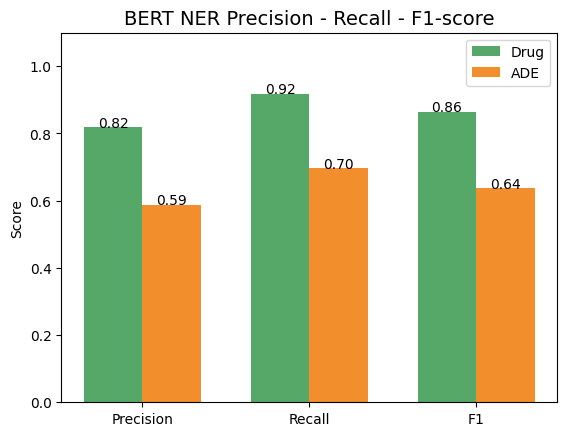

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("bert_ner_results.csv")

drug = df[df["Entity"] == "Drug"].iloc[0]
ade = df[df["Entity"] == "ADE"].iloc[0]

metrics = ["Precision", "Recall", "F1"]
drug_scores = [drug["Precision"], drug["Recall"], drug["F1"]]
ade_scores = [ade["Precision"], ade["Recall"], ade["F1"]]

x = np.arange(len(metrics))
width = 0.35

plt.figure()

# màu đẹp hơn (xanh dương + cam pastel)
bars1 = plt.bar(x - width/2, drug_scores, width, 
                label="Drug", color="#55A868")   # xanh lá

bars2 = plt.bar(x + width/2, ade_scores, width, 
                label="ADE", color="#F28E2B")    # cam đẹp

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("BERT NER Precision - Recall - F1-score", fontsize=14)

plt.legend()

# hiển thị số
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', fontsize=10)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', fontsize=10)

plt.ylim(0, 1.1)

plt.show()

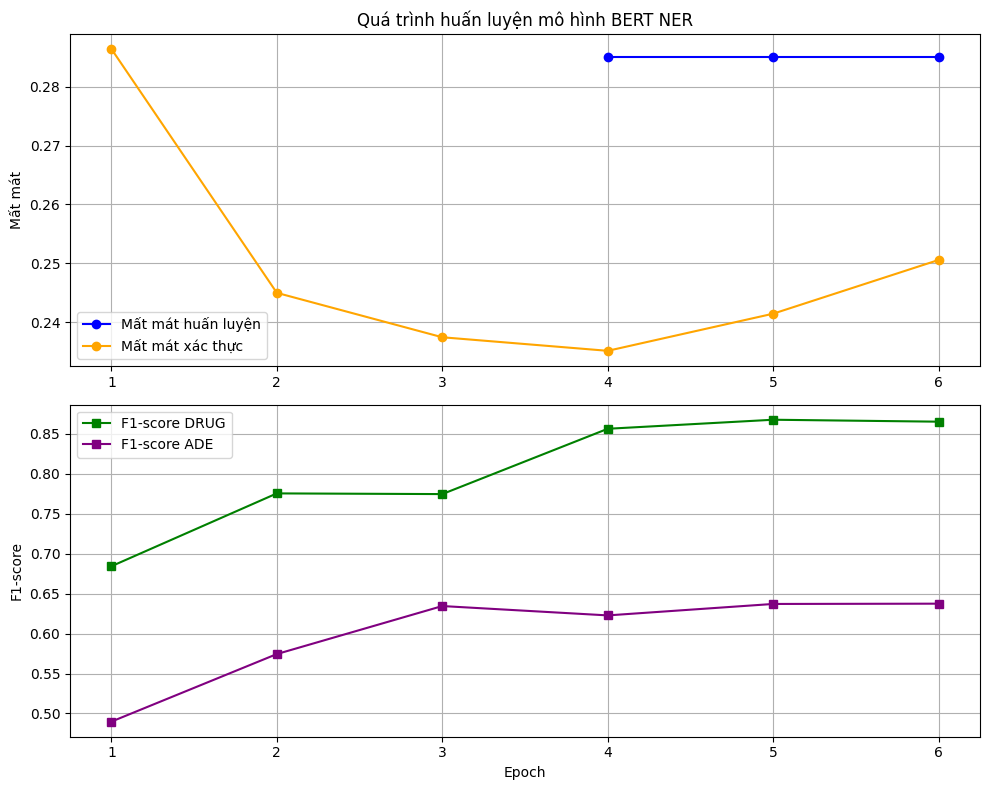

In [43]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5, 6]

# train_loss = [None, None, None, 0.274246, 0.274246, 0.274246]
# val_loss   = [0.281415, 0.244850, 0.227230, 0.233743, 0.239002, 0.248743]

# f1_drug = [0.700461, 0.769976, 0.787440, 0.840731, 0.861702, 0.852713]
# f1_ade  = [0.497254, 0.573045, 0.618342, 0.612653, 0.626374, 0.631057]


# ===== LOSS =====
train_loss = [None, None, None, 0.285158, 0.285158, 0.285158]
val_loss   = [0.286471, 0.244963, 0.237404, 0.235097, 0.241417, 0.250560]

# ===== F1-SCORE =====
f1_drug = [0.684337, 0.775510, 0.774648, 0.856410, 0.867725, 0.865285]
f1_ade  = [0.489816, 0.574402, 0.634498, 0.622788, 0.637119, 0.637472]


plt.figure(figsize=(10, 8))

# ===== Loss =====
plt.subplot(2, 1, 1)
plt.plot(epochs, train_loss, marker='o', color='blue', label='Mất mát huấn luyện')
plt.plot(epochs, val_loss, marker='o', color='orange', label='Mất mát xác thực')
plt.title("Quá trình huấn luyện mô hình BERT NER")
plt.ylabel("Mất mát")
plt.legend()
plt.grid(True)

# ===== F1 =====
plt.subplot(2, 1, 2)
plt.plot(epochs, f1_drug, marker='s', color='green', label='F1-score DRUG')
plt.plot(epochs, f1_ade, marker='s', color='purple', label='F1-score ADE')
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

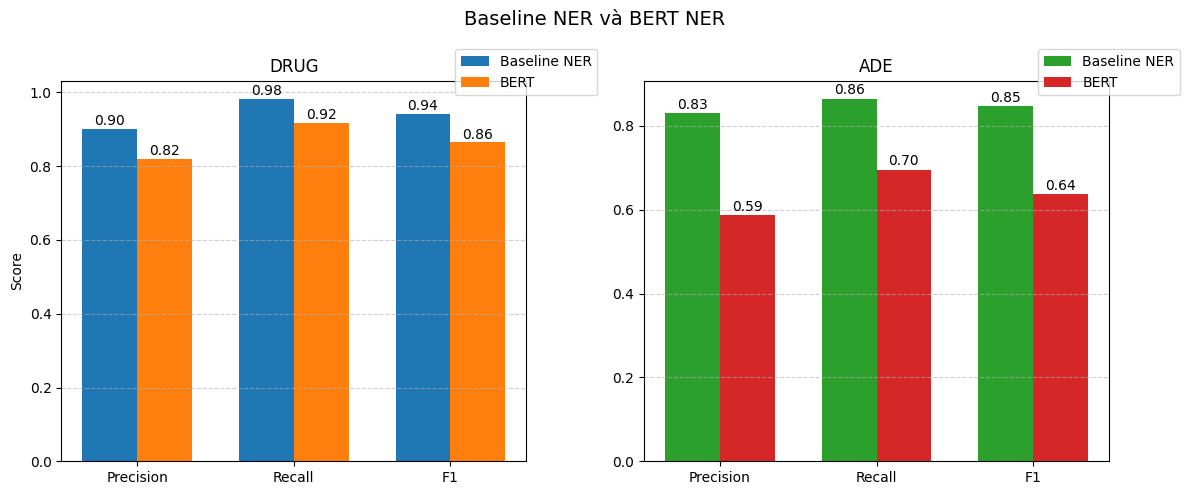

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===== BERT =====
bert_df = pd.read_csv("bert_ner_results.csv")

bert_drug = bert_df[bert_df["Entity"] == "Drug"].iloc[0]
bert_ade  = bert_df[bert_df["Entity"] == "ADE"].iloc[0]

bert_drug_scores = [bert_drug["Precision"], bert_drug["Recall"], bert_drug["F1"]]
bert_ade_scores  = [bert_ade["Precision"], bert_ade["Recall"], bert_ade["F1"]]

# ===== BASELINE =====
baseline_drug = [0.902, 0.983, 0.941]
baseline_ade  = [0.831, 0.865, 0.848]


metrics = ["Precision", "Recall", "F1"]
x = np.arange(len(metrics))
width = 0.35

# ===== TẠO 2 BIỂU ĐỒ TRÊN 1 HÀNG =====
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ================= DRUG =================
axes[0].bar(x - width/2, baseline_drug, width, color='#1f77b4', label="Baseline NER")   # xanh đậm
axes[0].bar(x + width/2, bert_drug_scores, width, color='#ff7f0e', label="BERT")    # cam

for i in range(len(metrics)):
    axes[0].text(x[i] - width/2, baseline_drug[i]+0.01, f"{baseline_drug[i]:.2f}", ha='center')
    axes[0].text(x[i] + width/2, bert_drug_scores[i]+0.01, f"{bert_drug_scores[i]:.2f}", ha='center')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title("DRUG")
axes[0].set_ylabel("Score")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[0].legend(loc='upper center', bbox_to_anchor=(1, 1.1))


# ================= ADE =================
axes[1].bar(x - width/2, baseline_ade, width, color='#2ca02c', label="Baseline NER")   # xanh lá
axes[1].bar(x + width/2, bert_ade_scores, width, color='#d62728', label="BERT")    # đỏ

for i in range(len(metrics)):
    axes[1].text(x[i] - width/2, baseline_ade[i]+0.01, f"{baseline_ade[i]:.2f}", ha='center')
    axes[1].text(x[i] + width/2, bert_ade_scores[i]+0.01, f"{bert_ade_scores[i]:.2f}", ha='center')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title("ADE")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].legend(loc='upper center', bbox_to_anchor=(1, 1.1))

# ===== CHUNG =====
plt.suptitle("Baseline NER và BERT NER", fontsize=14)

plt.tight_layout()
plt.savefig("compare_ner_subplot.png", dpi=300)
plt.show()

In [44]:
trainer.evaluate(eval_dataset=test_data)

 kết quả  bert_ner_results.csv


RuntimeError: on_train_begin must be called before on_evaluate

In [18]:
print("Chuẩn hóa bằng từ điển ngoài")

Chuẩn hóa bằng từ điển ngoài


In [16]:
# import re

# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"[^\w\s]", "", text)  
#     text = " ".join(text.split())        
#     return text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   
    text = re.sub(r"\s+", " ", text)       
    text = text.strip()
    return text

In [17]:
import pandas as pd

drug_data = [
    ("arthotec", "arthrotec"),
    ("arthrotec", "arthrotec"),
    ("tylenol", "paracetamol"),
    ("advil", "ibuprofen"),
]

df_drug = pd.DataFrame(drug_data, columns=["variant", "canonical"])
df_drug.to_csv("drug_normalization.csv", index=False)

In [18]:
ade_data = [
    ("slight nausea", "nausea"),
    ("feeling nauseous", "nausea"),
    ("abdominal cramps and pain", "abdominal cramps"),
    ("cramping pains in lower gut", "abdominal cramps"),
    ("extreme itching on legs and arms", "itching"),
      ("far no gastric", "gastric issue"),
    ("no gastric", "gastric issue"),
    ("gastric discomfort", "gastric issue")
]

df_ade = pd.DataFrame(ade_data, columns=["variant", "canonical"])
df_ade.to_csv("ade_normalization.csv", index=False)

In [19]:
import pandas as pds

def load_dict(path):
    df = pd.read_csv(path)
    return dict(zip(df["variant"], df["canonical"]))

drug_dict = load_dict("drug_normalization.csv")
ade_dict = load_dict("ade_normalization.csv")

In [20]:
def normalize_entity(text, label):
    text = text.lower().strip()

    if label == "DRUG":
        return drug_dict.get(text, text)

    elif label in ["ADR", "ADE"]:
        return ade_dict.get(text, text)

    return text

In [21]:
predictions, labels, _ = trainer.predict(test_data)
predictions = predictions.argmax(axis=2)

true_preds = []

for pred, lab in zip(predictions, labels):
    cur_preds = []
    for p_, l_ in zip(pred, lab):
        if l_ != -100:
            cur_preds.append(id2label[p_])
    true_preds.append(cur_preds)

 kết quả  bert_ner_results.csv


In [22]:
test_tokens = [sentences[i] for i in range(len(test_data))]

In [23]:
from seqeval.metrics.sequence_labeling import get_entities

def extract_entities(tokens, labels):
    entities = []
    for ent_type, start, end in get_entities(labels):
        text = " ".join(tokens[start:end+1])
        entities.append((text, ent_type))
    return entities

In [24]:

def normalize_entities(entities):
    normalized = []
    changed = []

    for text, label in entities:
        text_clean = clean_text(text)
        original = text_clean

        if label in ["ADR", "SYMPTOM"]:
            for k, v in sorted(ade_dict.items(), key=lambda x: -len(x[0])):
                if k in text_clean:
                    text_clean = v
                    break

        elif label == "DRUG":
            for k, v in sorted(drug_dict.items(), key=lambda x: -len(x[0])):
                if k in text_clean:
                    text_clean = v
                    break

        if original != text_clean:
            changed.append((original, text_clean, label))

        normalized.append((text_clean, label))

    return normalized, changed
all_changed = []

for i in range(len(test_tokens)):
    before = extract_entities(test_tokens[i], true_preds[i])
    after, changed = normalize_entities(before)

    all_changed.extend(changed)

print("=== CÁC ENTITY ĐÃ ĐƯỢC CHUẨN HÓA ===")
for c in all_changed[:30]:   
    print(c)

print("\nTổng số entity được normalize:", len(all_changed))

=== CÁC ENTITY ĐÃ ĐƯỢC CHUẨN HÓA ===
('far no gastric', 'gastric issue', 'ADR')
('tylenol', 'paracetamol', 'DRUG')

Tổng số entity được normalize: 2


In [25]:
i = 0  

tokens = test_tokens[i]
pred_labels = true_preds[i]

entities_before = extract_entities(tokens, pred_labels)

print("=== Trước NORMALIZE: ===")
for e in entities_before:
    print(e)

=== Trước NORMALIZE: ===
('far no gastric', 'ADR')


In [26]:
entities_after = normalize_entities(entities_before)

print("\n=== Sau NORMALIZE: ===")
for e in entities_after:
    print(e)


=== Sau NORMALIZE: ===
[('gastric issue', 'ADR')]
[('far no gastric', 'gastric issue', 'ADR')]


In [27]:
for i in range(10):
    tokens = test_tokens[i]
    pred_labels = true_preds[i]

    before = extract_entities(tokens, pred_labels)
    after = normalize_entities(before)

    print(f"\n===== CÂU {i} =====")

    print("NORMALIZE trước:")
    print(before)

    print("NORMALIZE sau:")
    print(after)


# for i in range(10):
#     tokens = test_tokens[i]
#     pred_labels = true_preds[i]

#     before = extract_entities(tokens, pred_labels)
#     after = normalize_entities(before)

#     print(f"\n===== CÂU {i} =====")

#     print("BEFORE:")
#     for x in before:
#         print(" ", x)

#     print("AFTER:")
#     for x in after:
#         print(" ", x)


===== CÂU 0 =====
NORMALIZE trước:
[('far no gastric', 'ADR')]
NORMALIZE sau:
([('gastric issue', 'ADR')], [('far no gastric', 'gastric issue', 'ADR')])

===== CÂU 1 =====
NORMALIZE trước:
[]
NORMALIZE sau:
([], [])

===== CÂU 2 =====
NORMALIZE trước:
[('no side effects for the', 'ADR'), ('first two months', 'ADR')]
NORMALIZE sau:
([('no side effects for the', 'ADR'), ('first two months', 'ADR')], [])

===== CÂU 3 =====
NORMALIZE trước:
[]
NORMALIZE sau:
([], [])

===== CÂU 4 =====
NORMALIZE trước:
[('side', 'DRUG'), ('side effects.', 'DRUG'), ('there are', 'ADR'), ('I', 'ADR')]
NORMALIZE sau:
([('side', 'DRUG'), ('side effects', 'DRUG'), ('there are', 'ADR'), ('i', 'ADR')], [])

===== CÂU 5 =====
NORMALIZE trước:
[('It seems as if', 'ADR'), ('forever', 'ADR'), ('a side effect but doctors tell', 'ADR'), ('not the drug I have been', 'ADR'), ('have pain', 'ADR'), ('first', 'ADR')]
NORMALIZE sau:
([('it seems as if', 'ADR'), ('forever', 'ADR'), ('a side effect but doctors tell', 'ADR'), 

In [28]:
# all_before = []
# all_after = []

# for i in range(len(test_tokens)):
#     tokens = test_tokens[i]
#     pred_labels = true_preds[i]

#     before = extract_entities(tokens, pred_labels)
#     after = normalize_entities(before)

#     # all_before.extend(before)
#     # all_after.extend(after)
        
#     all_before.extend([tuple(x) for x in before])
#     all_after.extend([tuple(x) for x in after])

all_before = []
all_after = []

for i in range(len(test_tokens)):
    tokens = test_tokens[i]
    pred_labels = true_preds[i]

    before = extract_entities(tokens, pred_labels)
    normalized, changed = normalize_entities(before)

    all_before.extend(before)
    all_after.extend(normalized)   

def count_unique(x):
    return len(set(x))

print("===== THỐNG KÊ =====")
print("Total BEFORE:", len(all_before))
print("Total AFTER :", len(all_after))

print("Unique BEFORE:", count_unique(all_before))
print("Unique AFTER :", count_unique(all_after))

print("Reduction:", count_unique(all_before) - count_unique(all_after))
print("Reduction %:", round(
    (count_unique(all_before) - count_unique(all_after)) / count_unique(all_before) * 100, 2
))

===== THỐNG KÊ =====
Total BEFORE: 1254
Total AFTER : 1254
Unique BEFORE: 846
Unique AFTER : 805
Reduction: 41
Reduction %: 4.85


In [30]:
from collections import Counter
import pandas as pd

# =========================================================
# GOM TOÀN BỘ ENTITY
# =========================================================
all_before = []
all_after = []

for i in range(len(test_tokens)):
    tokens = test_tokens[i]
    pred_labels = true_preds[i]

    before = extract_entities(tokens, pred_labels)
    normalized, changed = normalize_entities(before)

    all_before.extend(before)
    all_after.extend(normalized)

# =========================================================
# HÀM THỐNG KÊ
# =========================================================
def get_stats(entity_list):

    total_entities = len(entity_list)

    unique_entities = len(set(entity_list))

    duplicate_entities = total_entities - unique_entities

    return {
        "total": total_entities,
        "unique": unique_entities,
        "duplicate": duplicate_entities
    }

before_stats = get_stats(all_before)
after_stats = get_stats(all_after)

# =========================================================
# TÍNH MỨC GIẢM
# =========================================================
unique_reduction = before_stats["unique"] - after_stats["unique"]

duplicate_reduction = (
    before_stats["duplicate"] - after_stats["duplicate"]
)

if before_stats["duplicate"] > 0:
    duplicate_reduction_percent = round(
        duplicate_reduction / before_stats["duplicate"] * 100,
        2
    )
else:
    duplicate_reduction_percent = 0

# =========================================================
# HIỂN THỊ KẾT QUẢ
# =========================================================
print("\n==============================")
print("SO SÁNH TRƯỚC VÀ SAU CHUẨN HÓA")
print("==============================")

print(f"Tổng entity BEFORE : {before_stats['total']}")
print(f"Tổng entity AFTER  : {after_stats['total']}")

print()

print(f"Unique entity BEFORE : {before_stats['unique']}")
print(f"Unique entity AFTER  : {after_stats['unique']}")

print()

print(f"Duplicate BEFORE : {before_stats['duplicate']}")
print(f"Duplicate AFTER  : {after_stats['duplicate']}")

print()

print(f"Unique giảm : {unique_reduction}")

print(f"Duplicate giảm : {duplicate_reduction}")

print(f"Duplicate giảm (%) : {duplicate_reduction_percent}%")

# =========================================================
# TẠO BẢNG THỐNG KÊ
# =========================================================
comparison_df = pd.DataFrame({
    "Metric": [
        "Total Entity",
        "Unique Entity",
        "Duplicate Entity"
    ],
    "Before": [
        before_stats["total"],
        before_stats["unique"],
        before_stats["duplicate"]
    ],
    "After": [
        after_stats["total"],
        after_stats["unique"],
        after_stats["duplicate"]
    ]
})

print("\n===== BẢNG THỐNG KÊ =====")
print(comparison_df)


SO SÁNH TRƯỚC VÀ SAU CHUẨN HÓA
Tổng entity BEFORE : 1254
Tổng entity AFTER  : 1254

Unique entity BEFORE : 846
Unique entity AFTER  : 805

Duplicate BEFORE : 408
Duplicate AFTER  : 449

Unique giảm : 41
Duplicate giảm : -41
Duplicate giảm (%) : -10.05%

===== BẢNG THỐNG KÊ =====
             Metric  Before  After
0      Total Entity    1254   1254
1     Unique Entity     846    805
2  Duplicate Entity     408    449


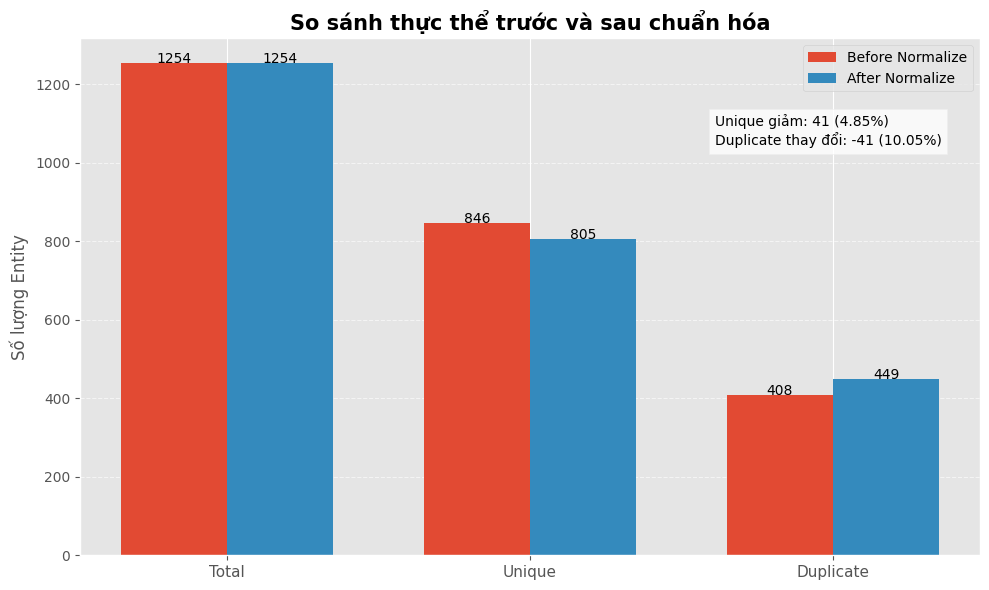

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# DỮ LIỆU
# =========================================================
metrics = ["Total", "Unique", "Duplicate"]

before_values = [
    before_stats["total"],
    before_stats["unique"],
    before_stats["duplicate"]
]

after_values = [
    after_stats["total"],
    after_stats["unique"],
    after_stats["duplicate"]
]

# =========================================================
# TÍNH % THAY ĐỔI
# =========================================================
unique_reduction_percent = round(
    (before_stats["unique"] - after_stats["unique"])
    / before_stats["unique"] * 100,
    2
)

duplicate_change_percent = round(
    (after_stats["duplicate"] - before_stats["duplicate"])
    / before_stats["duplicate"] * 100,
    2
)

# =========================================================
# VẼ BIỂU ĐỒ
# =========================================================
x = np.arange(len(metrics))
width = 0.35

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(
    x - width/2,
    before_values,
    width,
    label="Before Normalize"
)

bars2 = ax.bar(
    x + width/2,
    after_values,
    width,
    label="After Normalize"
)

# =========================================================
# TITLE & LABEL
# =========================================================
ax.set_title(
    "So sánh thực thể trước và sau chuẩn hóa",
    fontsize=15,
    weight="bold"
)

ax.set_ylabel("Số lượng Entity", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)

ax.legend()

# =========================================================
# HIỂN THỊ GIÁ TRỊ TRÊN CỘT
# =========================================================
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{int(height)}",
            ha='center',
            fontsize=10
        )

# =========================================================
# THÊM CHÚ THÍCH PHẦN GIẢM
# =========================================================
textstr = (
    f"Unique giảm: {unique_reduction} ({unique_reduction_percent}%)\n"
    f"Duplicate thay đổi: {duplicate_reduction} ({duplicate_change_percent}%)"
)

plt.gcf().text(
    0.72,
    0.75,
    textstr,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

# =========================================================
# GRID
# =========================================================
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

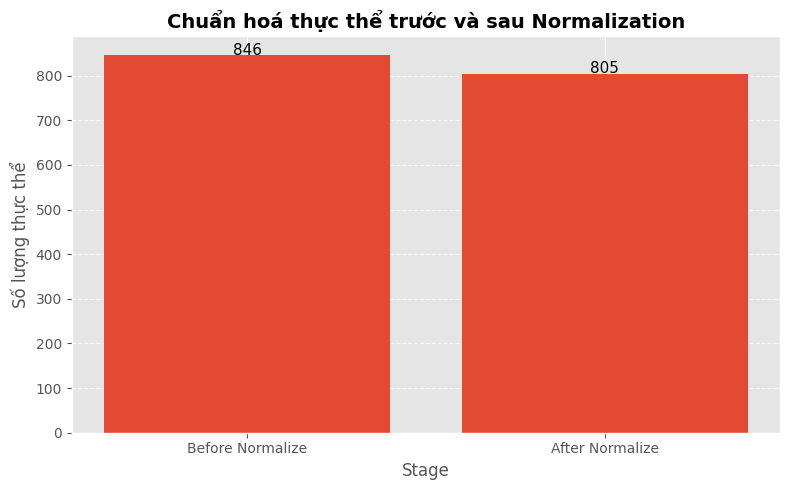

In [29]:
import matplotlib.pyplot as plt

before_unique = count_unique(all_before)
after_unique = count_unique(all_after)

labels = ["Before Normalize", "After Normalize"]
values = [before_unique, after_unique]

# Style tổng thể
plt.style.use('ggplot')

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

# Tiêu đề & nhãn
plt.title("Chuẩn hoá thực thể trước và sau Normalization", fontsize=14, weight='bold')
plt.ylabel("Số lượng thực thể", fontsize=12)
plt.xlabel("Stage", fontsize=12)

# Hiển thị giá trị trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{int(height)}',
             ha='center', fontsize=11)

# Grid nhẹ
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [45]:
print("Relation Extraction")

Relation Extraction


In [46]:
import re

# CAUSE_PATTERNS = [
#     r"after taking",
#     r"caused",
#     r"made me",
#     r"gave me",
#     r"because of",
#     r"due to"
# ]

# NEGATION_PATTERNS = [
#     r"not",
#     r"no",
#     r"did not",
#     r"never",
#     r"don't think",
#     r"doesn't seem"
# ]

CAUSE_PATTERNS = [
    r"after taking",
    r"after .* taking",
    r"caused",
    r"cause",
    r"made me",
    r"gave me",
    r"stopped because of",
    r"because of",
    r"due to",
    r"led to",
    r"resulted in",
    r"i got",
    r"i have",
    r"i developed",
    r"after i took"
]
NEGATION_PATTERNS = [
    r"no ",
    r"not ",
    r"did not",
    r"never",
    r"without",
    r"no side effects",
    r"did not think caused"
]

In [47]:
# def is_valid_entity(text):
#     text = text.strip().lower()
#     if len(text) < 3:
#         return False
#     if text in ["a", "an", "the", "it", "i", ""]:
#         return False
#     return True
# lần 2
def is_valid_entity(text):
    text = text.strip().lower()

    
    if len(text) < 3:
        return False


    stopwords = {
        "a", "an", "the", "it", "i", "and", "or",
        "with", "because", "this", "that", "these",
        "those", "there", "have", "had", "been"
    }
    if text in stopwords:
        return False

    if text.isdigit():
        return False

    
    if len(text.split()) == 1 and not text.isalpha():
        return False

    return True

In [48]:
# def is_valid_drug(text):
#     text = text.lower()

#     bad = {
#         "pain", "problem", "effect", "thing",
#         "medicine", "drug", "this", "it"
#     }

#     if text in bad:
#         return False

#     return is_valid_entity(text)

# 
def is_valid_drug(text):
    text = text.lower().strip()

    bad = {
        "pain", "problem", "effect", "thing",
        "this", "it", ""
    }

    if text in bad or len(text) < 3:
        return False

    return True

In [ ]:
# def has_causal_context(sentence):
#     s = sentence.lower()
#     return any(p in s for p in CAUSE_PATTERNS)

# def has_negation(sentence):
#     s = sentence.lower()
#     return any(p in s for p in NEGATION_PATTERNS)

In [ ]:
# def extract_relations(sent_tokens, entities):
#     sentence = " ".join(sent_tokens)
#     relations = []

#     drugs = [e for e in entities if e[1] == "DRUG"]
#     ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

  
#     if has_negation(sentence):
#         return relations  

#     if not has_causal_context(sentence):
#         return relations  

#     for d in drugs:
#         for a in ades:
#             relations.append((d[0], "CAUSES", a[0]))

#     return relations

In [ ]:
# all_relations = []

# for i in range(len(test_tokens)):
#     tokens = test_tokens[i]
#     sentence = " ".join(tokens)
#     pred_labels = true_preds[i]

#     entities = extract_entities(tokens, pred_labels)
#     relations = extract_relations(tokens, entities)

#     all_relations.extend(relations)

#     print(f"\n===== CÂU {i} =====")
#     print("Sentence:", sentence)
#     print("Entities:", entities)
#     print("Relations BEFORE/AFTER RULES:")
#     print(relations)

In [49]:
# # import re

# # def has_cause(text):
# #     return any(re.search(p, text) for p in CAUSE_PATTERNS)

# # def has_negation(text):
# #     return any(re.search(p, text) for p in NEGATION_PATTERNS)


# # def extract_relations(sent_tokens, entities):
# #     sentence = " ".join(sent_tokens).lower()
# #     relations = []

# #     drugs = [e for e in entities if e[1] == "DRUG"]
# #     ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

# #     for d_text, _ in drugs:
# #         for a_text, _ in ades:

# #             d = d_text.lower()
# #             a = a_text.lower()

# #             if d not in sentence or a not in sentence:
# #                 continue

           
# #             d_idx = sentence.find(d)
# #             a_idx = sentence.find(a)

# #             start = min(d_idx, a_idx)
# #             end   = max(d_idx, a_idx)

# #             context = sentence[start:end]

         
# #             if has_negation(context):
# #                 continue

          
# #             if has_cause(context) or abs(d_idx - a_idx) < 40:
# #                 relations.append((d_text, "CAUSES", a_text))

# #     return relations
# # lan 2
# # def extract_relations(sent_tokens, entities):
# #     sentence = " ".join(sent_tokens).lower()
# #     relations = []

# #     drugs = [e for e in entities if e[1] == "DRUG"]
# #     ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

# #     for d_text, _ in drugs:
# #         for a_text, _ in ades:

           
# #             if not is_valid_entity(d_text) or not is_valid_entity(a_text):
# #                 continue

# #             d = d_text.lower()
# #             a = a_text.lower()

# #             if d not in sentence or a not in sentence:
# #                 continue

# #             d_idx = sentence.find(d)
# #             a_idx = sentence.find(a)

           
# #             if a_idx < d_idx:
# #                 continue

            
# #             window = 50
# #             context = sentence[max(0, d_idx-window): min(len(sentence), a_idx+window)]

          
# #             if has_negation(context):
# #                 continue

          
# #             if has_cause(context):
# #                 relations.append((d_text, "CAUSES", a_text))

# #     return relations

# import re

# def has_cause(text):
#     for p in CAUSE_PATTERNS:
#         if re.search(p, text):
#             return True
#     return False


# def has_negation(text):
#     for p in NEGATION_PATTERNS:
#         if re.search(p, text):
#             return True
#     return False
    
# def extract_relations(sent_tokens, entities):
#     sentence = " ".join(sent_tokens).lower()
#     relations = []

#     drugs = [e for e in entities if e[1] == "DRUG"]
#     ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

#     for d_text, _ in drugs:
#         for a_text, _ in ades:

#             if not is_valid_drug(d_text) or not is_valid_entity(a_text):
#                 continue

#             d = d_text.lower()
#             a = a_text.lower()

#             if d not in sentence or a not in sentence:
#                 continue

#             d_idx = sentence.find(d)
#             a_idx = sentence.find(a)

            
#             if a_idx < d_idx:
#                 continue

           
#             if abs(a_idx - d_idx) < 100:
#                 continue

           
#             # context = sentence[max(0, d_idx-30): min(len(sentence), a_idx+30)]
#             context = sentence[max(0, d_idx-50): min(len(sentence), a_idx+50)]
            
#             if has_negation(context):
#                 continue

                       
#             if has_cause(context):
#                 pass
            
           
#             # elif abs(a_idx - d_idx) < 40:
#             elif abs(a_idx - d_idx) < 80:
#                 pass
#             else:
#                 continue

#             relations.append((d_text, "CAUSES", a_text))

#     return relations


# mới
# import re

import re

def has_cause(text):
    for p in CAUSE_PATTERNS:
        if re.search(p, text):
            return True
    return False


def has_negation(text):
    for p in NEGATION_PATTERNS:
        if re.search(p, text):
            return True
    return False

    
def extract_relations(sent_tokens, entities):
    sentence = " ".join(sent_tokens).lower()
    relations = []

    drugs = [e for e in entities if e[1] == "DRUG"]
    ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

    for d_text, _ in drugs:
        for a_text, _ in ades:

            if not is_valid_drug(d_text) or not is_valid_entity(a_text):
                continue

            d = d_text.lower()
            a = a_text.lower()

            if d not in sentence or a not in sentence:
                continue

            d_idx = sentence.find(d)
            a_idx = sentence.find(a)

            
            if a_idx < d_idx:
                continue

            distance = a_idx - d_idx

           
            context = sentence[max(0, d_idx-50): min(len(sentence), a_idx+50)]

          
            if has_negation(context):
                continue

           
            if has_cause(context):
                relations.append((d_text, "CAUSES", a_text))
                continue

         
            if "after taking" in context or "after i took" in context:
                relations.append((d_text, "CAUSES", a_text))
                continue

           
            if distance < 80:
                relations.append((d_text, "CAUSES", a_text))

    return relations

In [50]:
for i in range(10):
    tokens = test_tokens[i]
    sentence = " ".join(tokens)
    labels = true_preds[i]

    entities = extract_entities(tokens, labels)

    
    relations_before = []
    drugs = [e for e in entities if e[1] == "DRUG"]
    ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

    for d in drugs:
        for a in ades:
            relations_before.append((d[0], "CAUSES", a[0]))

  
    relations_after = extract_relations(tokens, entities)

    print(f"\n===== CÂU {i} =====")
    print("Sentence:", sentence)
    print("Entities:", entities)

    print("\nBEFORE:")
    print(relations_before)

    print("\nAFTER:")
    print(relations_after)


===== CÂU 0 =====
Sentence: I feel a bit drowsy & have a little blurred vision, so far no gastric problems. I've been on Arthrotec 50 for over 10 years on and off, only taking it when I needed it. Due to my arthritis getting progressively worse, to the point where I am in tears with the agony, gp's started me on 75 twice a day and I have to take it. every day for the next month to see how I get on, here goes. So far its been very good, pains almost gone, but I feel a bit weird, didn't have that when on 50.
Entities: [('far no gastric', 'ADR')]

BEFORE:
[]

AFTER:
[]

===== CÂU 1 =====
Sentence: Hunger pangs. Brilliant, I have a new lease of life, i walk up & down steps properly, no longer sideways like a toddler, hip pain as gone other than if i jar it.
Entities: []

BEFORE:
[]

AFTER:
[]

===== CÂU 2 =====
Sentence: no side effects for the first two months . then vaginal bleeding 2 wks after menstral cycle. stomach pain. canker sores in my mouth. headache. been off for 1 week still h

In [51]:
all_before = []
all_after = []

for i in range(len(test_tokens)):
    tokens = test_tokens[i]
    labels = true_preds[i]

    entities = extract_entities(tokens, labels)

    drugs = [e for e in entities if e[1] == "DRUG"]
    ades  = [e for e in entities if e[1] in ["ADR", "ADE", "SYMPTOM"]]

    for d in drugs:
        for a in ades:
            all_before.append((d[0], "CAUSES", a[0]))

    relations_after = extract_relations(tokens, entities)
    all_after.extend(relations_after)


def count_unique(x):
    return len(set(x))


print("===== THỐNG KÊ RELATION =====")
print("Total BEFORE:", len(all_before))
print("Total AFTER :", len(all_after))

print("Unique BEFORE:", count_unique(all_before))
print("Unique AFTER :", count_unique(all_after))

print("Reduction:", count_unique(all_before) - count_unique(all_after))
print("Reduction %:", round(
    (count_unique(all_before) - count_unique(all_after)) / count_unique(all_before) * 100, 2
))

===== THỐNG KÊ RELATION =====
Total BEFORE: 832
Total AFTER : 46
Unique BEFORE: 613
Unique AFTER : 46
Reduction: 567
Reduction %: 92.5


In [52]:
removed = set(all_before) - set(all_after)

print("\n=== RELATIONS BỊ LOẠI (FP) ===")
for r in list(removed)[:20]:
    print(r)


=== RELATIONS BỊ LOẠI (FP) ===
('I', 'CAUSES', 'well')
('completely', 'CAUSES', "about Lipitor's")
('', 'CAUSES', 'in any')
('', 'CAUSES', '4 month without')
('will', 'CAUSES', 'but')
('and', 'CAUSES', 'the')
('will', 'CAUSES', 'though')
('pain', 'CAUSES', 'Medicine from')
('', 'CAUSES', 'vision,')
('did', 'CAUSES', 'only')
('a', 'CAUSES', 'component I experienced worse')
('medicine', 'CAUSES', 'worse and')
('all', 'CAUSES', 'down.')
('1/2', 'CAUSES', 'breath')
('sleep,', 'CAUSES', 'for me.')
('cannot', 'CAUSES', 'my cholesterol')
('doctor', 'CAUSES', 'was')
('stopped', 'CAUSES', '')
('started', 'CAUSES', '100%')
('pounds,', 'CAUSES', 'Before I')


In [53]:
print("\n=== RELATIONS SAU KHI LỌC ===")
for r in list(set(all_after))[:20]:
    print(r)


=== RELATIONS SAU KHI LỌC ===
('Multiple', 'CAUSES', 'am a')
('and', 'CAUSES', 'day anymore.')
('started', 'CAUSES', 'being menopausal')
('mini', 'CAUSES', 'I wake up.')
('uterine', 'CAUSES', 'Alot')
('These', 'CAUSES', 'My stomach is still sore when palpitated')
('only', 'CAUSES', 'two a')
('because', 'CAUSES', 'passed, but its been a')
('only', 'CAUSES', 'day approx.')
('got', 'CAUSES', 'begin')
('pounds,', 'CAUSES', 'dysfunction in')
('completely', 'CAUSES', 'of 10mg')
('because', 'CAUSES', 'period cramps')
('been', 'CAUSES', 'dysfunction in')
('Lipitor', 'CAUSES', 'I started')
('uterine', 'CAUSES', 'cause me more pain.')
('Lipitor', 'CAUSES', 'EXTREMELY')
('got', 'CAUSES', 'you')
('1/2', 'CAUSES', 'over')
('uterine', 'CAUSES', 'much worst than the')


In [54]:
def is_suspicious(rel):
    d, _, a = rel
    bad = ["i", "doctor", "medicine", "it", "this", "thing", "there", "have"]
    return d.lower() in bad or a.lower() in bad


print("\n=== FP CÒN SÓT TRONG AFTER ===")
for r in set(all_after):
    if is_suspicious(r):
        print(r)


=== FP CÒN SÓT TRONG AFTER ===
('Have', 'CAUSES', '2-3/wk during')
('have', 'CAUSES', 'face. its falling off.')
('have', 'CAUSES', 'better. But')


In [55]:
FN = set(all_before) - set(all_after)

print("\n=== FALSE NEGATIVES (bị mất đúng relation) ===")
for r in list(FN)[:30]:
    print(r)


=== FALSE NEGATIVES (bị mất đúng relation) ===
('I', 'CAUSES', 'well')
('completely', 'CAUSES', "about Lipitor's")
('', 'CAUSES', 'in any')
('', 'CAUSES', '4 month without')
('will', 'CAUSES', 'but')
('and', 'CAUSES', 'the')
('will', 'CAUSES', 'though')
('pain', 'CAUSES', 'Medicine from')
('', 'CAUSES', 'vision,')
('did', 'CAUSES', 'only')
('a', 'CAUSES', 'component I experienced worse')
('medicine', 'CAUSES', 'worse and')
('all', 'CAUSES', 'down.')
('1/2', 'CAUSES', 'breath')
('sleep,', 'CAUSES', 'for me.')
('cannot', 'CAUSES', 'my cholesterol')
('doctor', 'CAUSES', 'was')
('stopped', 'CAUSES', '')
('started', 'CAUSES', '100%')
('pounds,', 'CAUSES', 'Before I')
('', 'CAUSES', '')
('wear', 'CAUSES', '.')
('side effects.', 'CAUSES', 'I')
('of', 'CAUSES', 'Soon')
('cold', 'CAUSES', '15')
('been', 'CAUSES', 'Before I')
('in', 'CAUSES', 'day 12')
('', 'CAUSES', 'Very very')
('stomach', 'CAUSES', "do I can't. MISERABLE!!.")
('of', 'CAUSES', 'stomach pain, constipation, uterine, cramps')


In [56]:
# trình bày lại dưới dạng bảng rõ ràng
# import pandas as pd

# before_total = len(all_before)
# after_total = len(all_after)

# before_unique = len(set(all_before))
# after_unique = len(set(all_after))

# removed = before_unique - after_unique
# reduction_percent = (removed / before_unique) * 100

# df = pd.DataFrame([
#     ["Before", before_total, before_unique, 0, 0],
#     ["After", after_total, after_unique, removed, reduction_percent]
# ], columns=["Stage", "Total", "Unique", "Removed", "Reduction %"])

# df.to_csv("relation_result.csv", index=False)

# print(

import pandas as pd

before_set = set(all_before)
after_set = set(all_after)

def count_fp(relations):
    return sum(1 for r in relations if is_suspicious(r))

FP_before = count_fp(before_set)
FP_after = count_fp(after_set)

TP_before = len(before_set) - FP_before
TP_after = len(after_set) - FP_after

removed = len(before_set) - len(after_set)
reduction_percent = removed / len(before_set) * 100

precision_before = TP_before / (TP_before + FP_before) if (TP_before + FP_before) else 0
precision_after = TP_after / (TP_after + FP_after) if (TP_after + FP_after) else 0
precision_change = precision_after - precision_before

df = pd.DataFrame([
    ["Ban đầu", len(before_set), TP_before, FP_before, 0, 0, precision_before],
    ["Sau lọc",  len(after_set),  TP_after,  FP_after,  removed, reduction_percent, precision_after]
], columns=["Sate", "Total", "Số đúng (TP)", "Số sai (FP)", "Số bị loại", "Tỉ lệ (%)", "Precision"])


df["Precision"] = df["Precision"].round(3)
df["Tỉ lệ (%)"] = df["Tỉ lệ (%)"].round(2)

df.to_csv("relation_result_final.csv", index=False, float_format="%.3f")
print(df)

print("\nPrecision cải thiện:", round(precision_change, 3))


      Sate  Total  Số đúng (TP)  Số sai (FP)  Số bị loại  Tỉ lệ (%)  Precision
0  Ban đầu    613           547           66           0        0.0      0.892
1  Sau lọc     46            43            3         567       92.5      0.935

Precision cải thiện: 0.042


In [67]:
# import pandas as pd

# before = set(all_before)
# after = set(all_after)

# # =========================
# # TÍNH ĐÚNGs
# # =========================
# TP = len(before & after)
# FP = len(after - before)
# FN = len(before - after)

# precision = TP / (TP + FP) if (TP + FP) > 0 else 0
# recall = TP / (TP + FN) if (TP + FN) > 0 else 0
# f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# # =========================
# # BẢNG KẾT QUẢ
# # =========================
# df = pd.DataFrame([{
#     "TP": TP,
#     "FP": FP,
#     "FN": FN,
#     "Precision": round(precision, 3),
#     "Recall": round(recall, 3),
#     "F1-score": round(f1, 3)
# }])

# print("===== RELATION EXTRACTION CẢI TIẾN =====")
# print(df)
import pandas as pd

before_set = set(all_before)
after_set = set(all_after)

def count_fp(relations):
    return sum(1 for r in relations if is_suspicious(r))

FP_before = count_fp(before_set)
FP_after = count_fp(after_set)

TP_before = len(before_set) - FP_before
TP_after = len(after_set) - FP_after

FN_after = len(before_set) - len(after_set)

precision_after = TP_after / (TP_after + FP_after) if (TP_after + FP_after) else 0
recall_after = TP_after / (TP_after + FN_after) if (TP_after + FN_after) else 0
f1_after = 2 * precision_after * recall_after / (precision_after + recall_after) if (precision_after + recall_after) else 0

df = pd.DataFrame([{
    "TP": TP_after,
    "FP": FP_after,
    "FN": FN_after,
    "Precision": round(precision_after, 3),
    "Recall": round(recall_after, 3),
    "F1-score": round(f1_after, 3)
}])

print(df)

   TP  FP   FN  Precision  Recall  F1-score
0  43   3  567      0.935    0.07     0.131


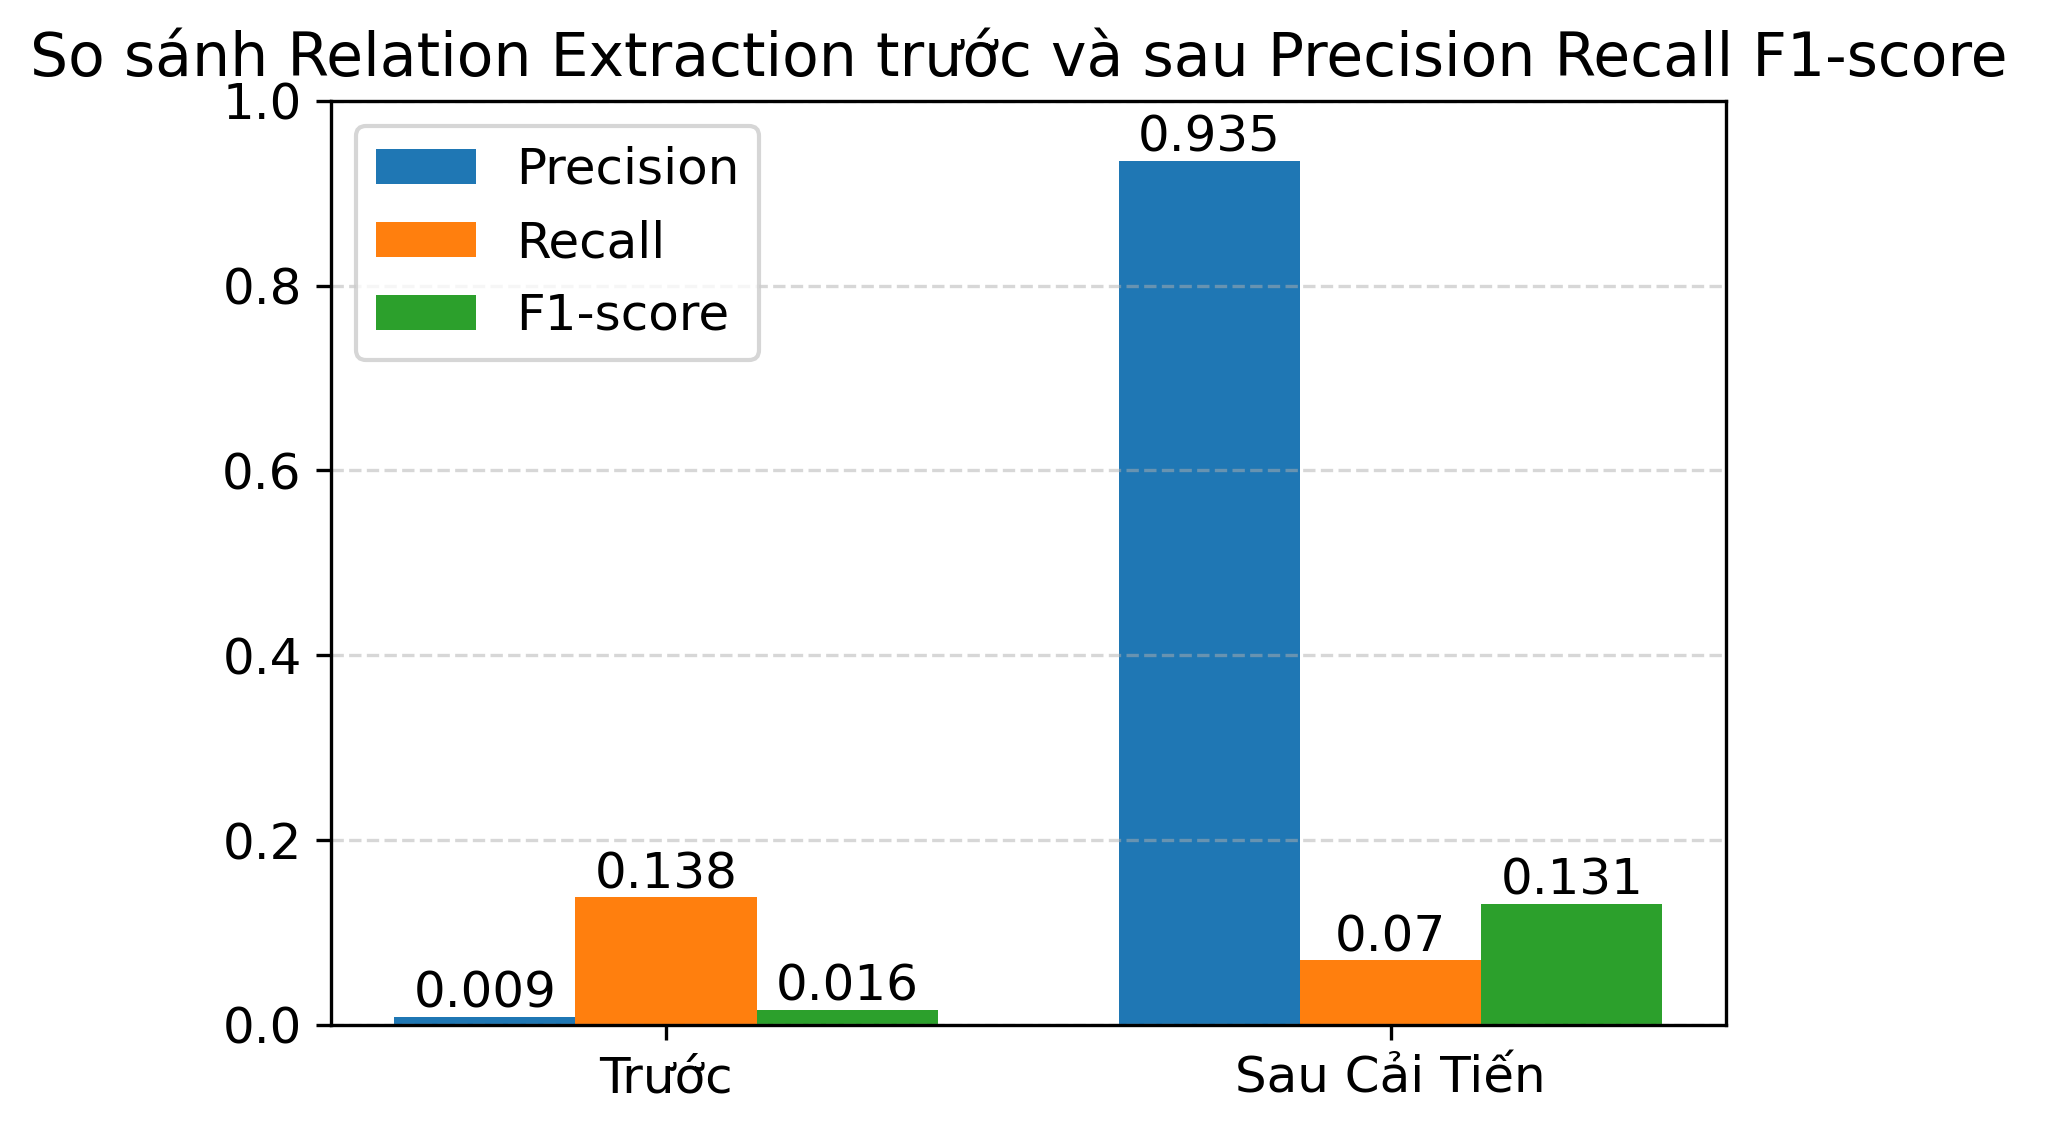

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA
# =========================
data = {
    "Model": ["Trước", "Sau Cải Tiến"],
    "Precision": [0.009, 0.935],
    "Recall": [0.138, 0.07],
    "F1-score": [0.016, 0.131]
}

df = pd.DataFrame(data)

# =========================
# BAR CHART SETUP
# =========================
x = np.arange(len(df["Model"]))  # vị trí cột
width = 0.25

plt.figure(figsize=(6,4))

# =========================
# 3 NHÓM CỘT
# =========================
plt.bar(x - width, df["Precision"], width=width, label="Precision")
plt.bar(x, df["Recall"], width=width, label="Recall")
plt.bar(x + width, df["F1-score"], width=width, label="F1-score")

# =========================
# LABEL X
# =========================
plt.xticks(x, df["Model"])

# =========================
# TITLE
# =========================
plt.title("So sánh Relation Extraction trước và sau Precision Recall F1-score ")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

# =========================
# GHI GIÁ TRỊ LÊN CỘT
# =========================
for i in range(len(x)):
    plt.text(x[i] - width, df["Precision"][i] + 0.01, round(df["Precision"][i], 3), ha="center")
    plt.text(x[i], df["Recall"][i] + 0.01, round(df["Recall"][i], 3), ha="center")
    plt.text(x[i] + width, df["F1-score"][i] + 0.01, round(df["F1-score"][i], 3), ha="center")

plt.show()

In [57]:
import csv
import os

# =========================
# OUTPUT
# =========================
output_folder = "phan_tich_loi"
os.makedirs(output_folder, exist_ok=True)

# =========================
# DATA
# =========================
before = set(all_before)
after = set(all_after)

removed = before - after
fn_set = before - after

# =========================
# NORMALIZE
# =========================
def norm(x):
    return x.lower().strip()

# =========================
# DOMAIN KNOWLEDGE (y khoa cơ bản)
# =========================
known_drugs = {"lipitor", "advil", "tylenol"}

negation_words = {"no", "not", "never", "didn't", "dont", "don't"}

# =========================
# HỌC THUẬT: 5 NHÓM NGUYÊN NHÂN LỖI
# =========================

# (1) NER bỏ sót / sai thực thể y khoa
ner_missing_errors = []

# (2) Nhiều thuốc / nhiều thực thể trong 1 câu (multi-entity ambiguity)
multi_drug_errors = []

# (3) Phủ định (negation scope error)
negation_errors = []

# (4) Tách câu / boundary error
segmentation_errors = []

# (5) Luật lọc quá mạnh → FN
overfilter_fn_errors = []

# =========================
# FP ANALYSIS (removed)
# =========================
for d, r, a in removed:

    d_n, a_n = norm(d), norm(a)

    # (4) segmentation error
    if d.strip() == "" or a.strip() == "":
        segmentation_errors.append((d, r, a))
        continue

    # (3) negation error
    if any(w in d_n or w in a_n for w in negation_words):
        negation_errors.append((d, r, a))
        continue

    # (2) multi-drug / multi-entity
    # câu dài hoặc chứa nhiều cụm thực thể
    if len(d.split()) > 4 or len(a.split()) > 6:
        multi_drug_errors.append((d, r, a))
        continue

    # (1) NER error (thuốc không nhận diện đúng / ngoài knowledge)
    if d_n not in known_drugs and len(d.split()) <= 2:
        ner_missing_errors.append((d, r, a))
        continue

    # fallback
    ner_missing_errors.append((d, r, a))

# =========================
# FN ANALYSIS (important)
# =========================
for d, r, a in fn_set:

    d_n, a_n = norm(d), norm(a)

    # (4) segmentation
    if d.strip() == "" or a.strip() == "":
        segmentation_errors.append((d, r, a))
        continue

    # (5) over-filtering FN (RULE-BASED LOẠI NHẦM)
    if d_n in negation_words or a_n in negation_words:
        overfilter_fn_errors.append((d, r, a))
        continue

    # (2) multi-entity FN
    if len(d.split()) > 4 or len(a.split()) > 6:
        multi_drug_errors.append((d, r, a))
        continue

    # (1) default: NER/model miss
    ner_missing_errors.append((d, r, a))

# =========================
# SAVE
# =========================
def save(name, data):
    with open(os.path.join(output_folder, name), "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["Drug", "Relation", "ADE"])
        w.writerows(data)

save("ner_bo_sot_thuat_ngu.csv", ner_missing_errors)
save("nhieu_thuoc_trong_cau.csv", multi_drug_errors)
save("phu_dinh_error.csv", negation_errors)
save("tach_cau_loi.csv", segmentation_errors)
save("luat_loc_qua_manh_fn.csv", overfilter_fn_errors)

# =========================
# STATISTICS
# =========================
print("=== ERROR ANALYSIS (THEO NGUYÊN NHÂN) ===")

print("NER bỏ sót:", len(ner_missing_errors))
print("Nhiều thuốc / multi-entity:", len(multi_drug_errors))
print("Phủ định:", len(negation_errors))
print("Tách câu:", len(segmentation_errors))
print("Over-filter FN:", len(overfilter_fn_errors))

=== ERROR ANALYSIS (THEO NGUYÊN NHÂN) ===
NER bỏ sót: 774
Nhiều thuốc / multi-entity: 27
Phủ định: 47
Tách câu: 268
Over-filter FN: 18


Đã phân tích: 567 lỗi

=== TỔNG HỢP LỖI ===
                         Nhom_Loi  So_Luong
0     NER bỏ sót thuật ngữ y khoa       147
1  Nhiều thuốc/thực thể trong câu        35
2                    Lỗi phủ định        43
3                    Lỗi tách câu       184
4        Luật lọc quá mạnh gây FN       158


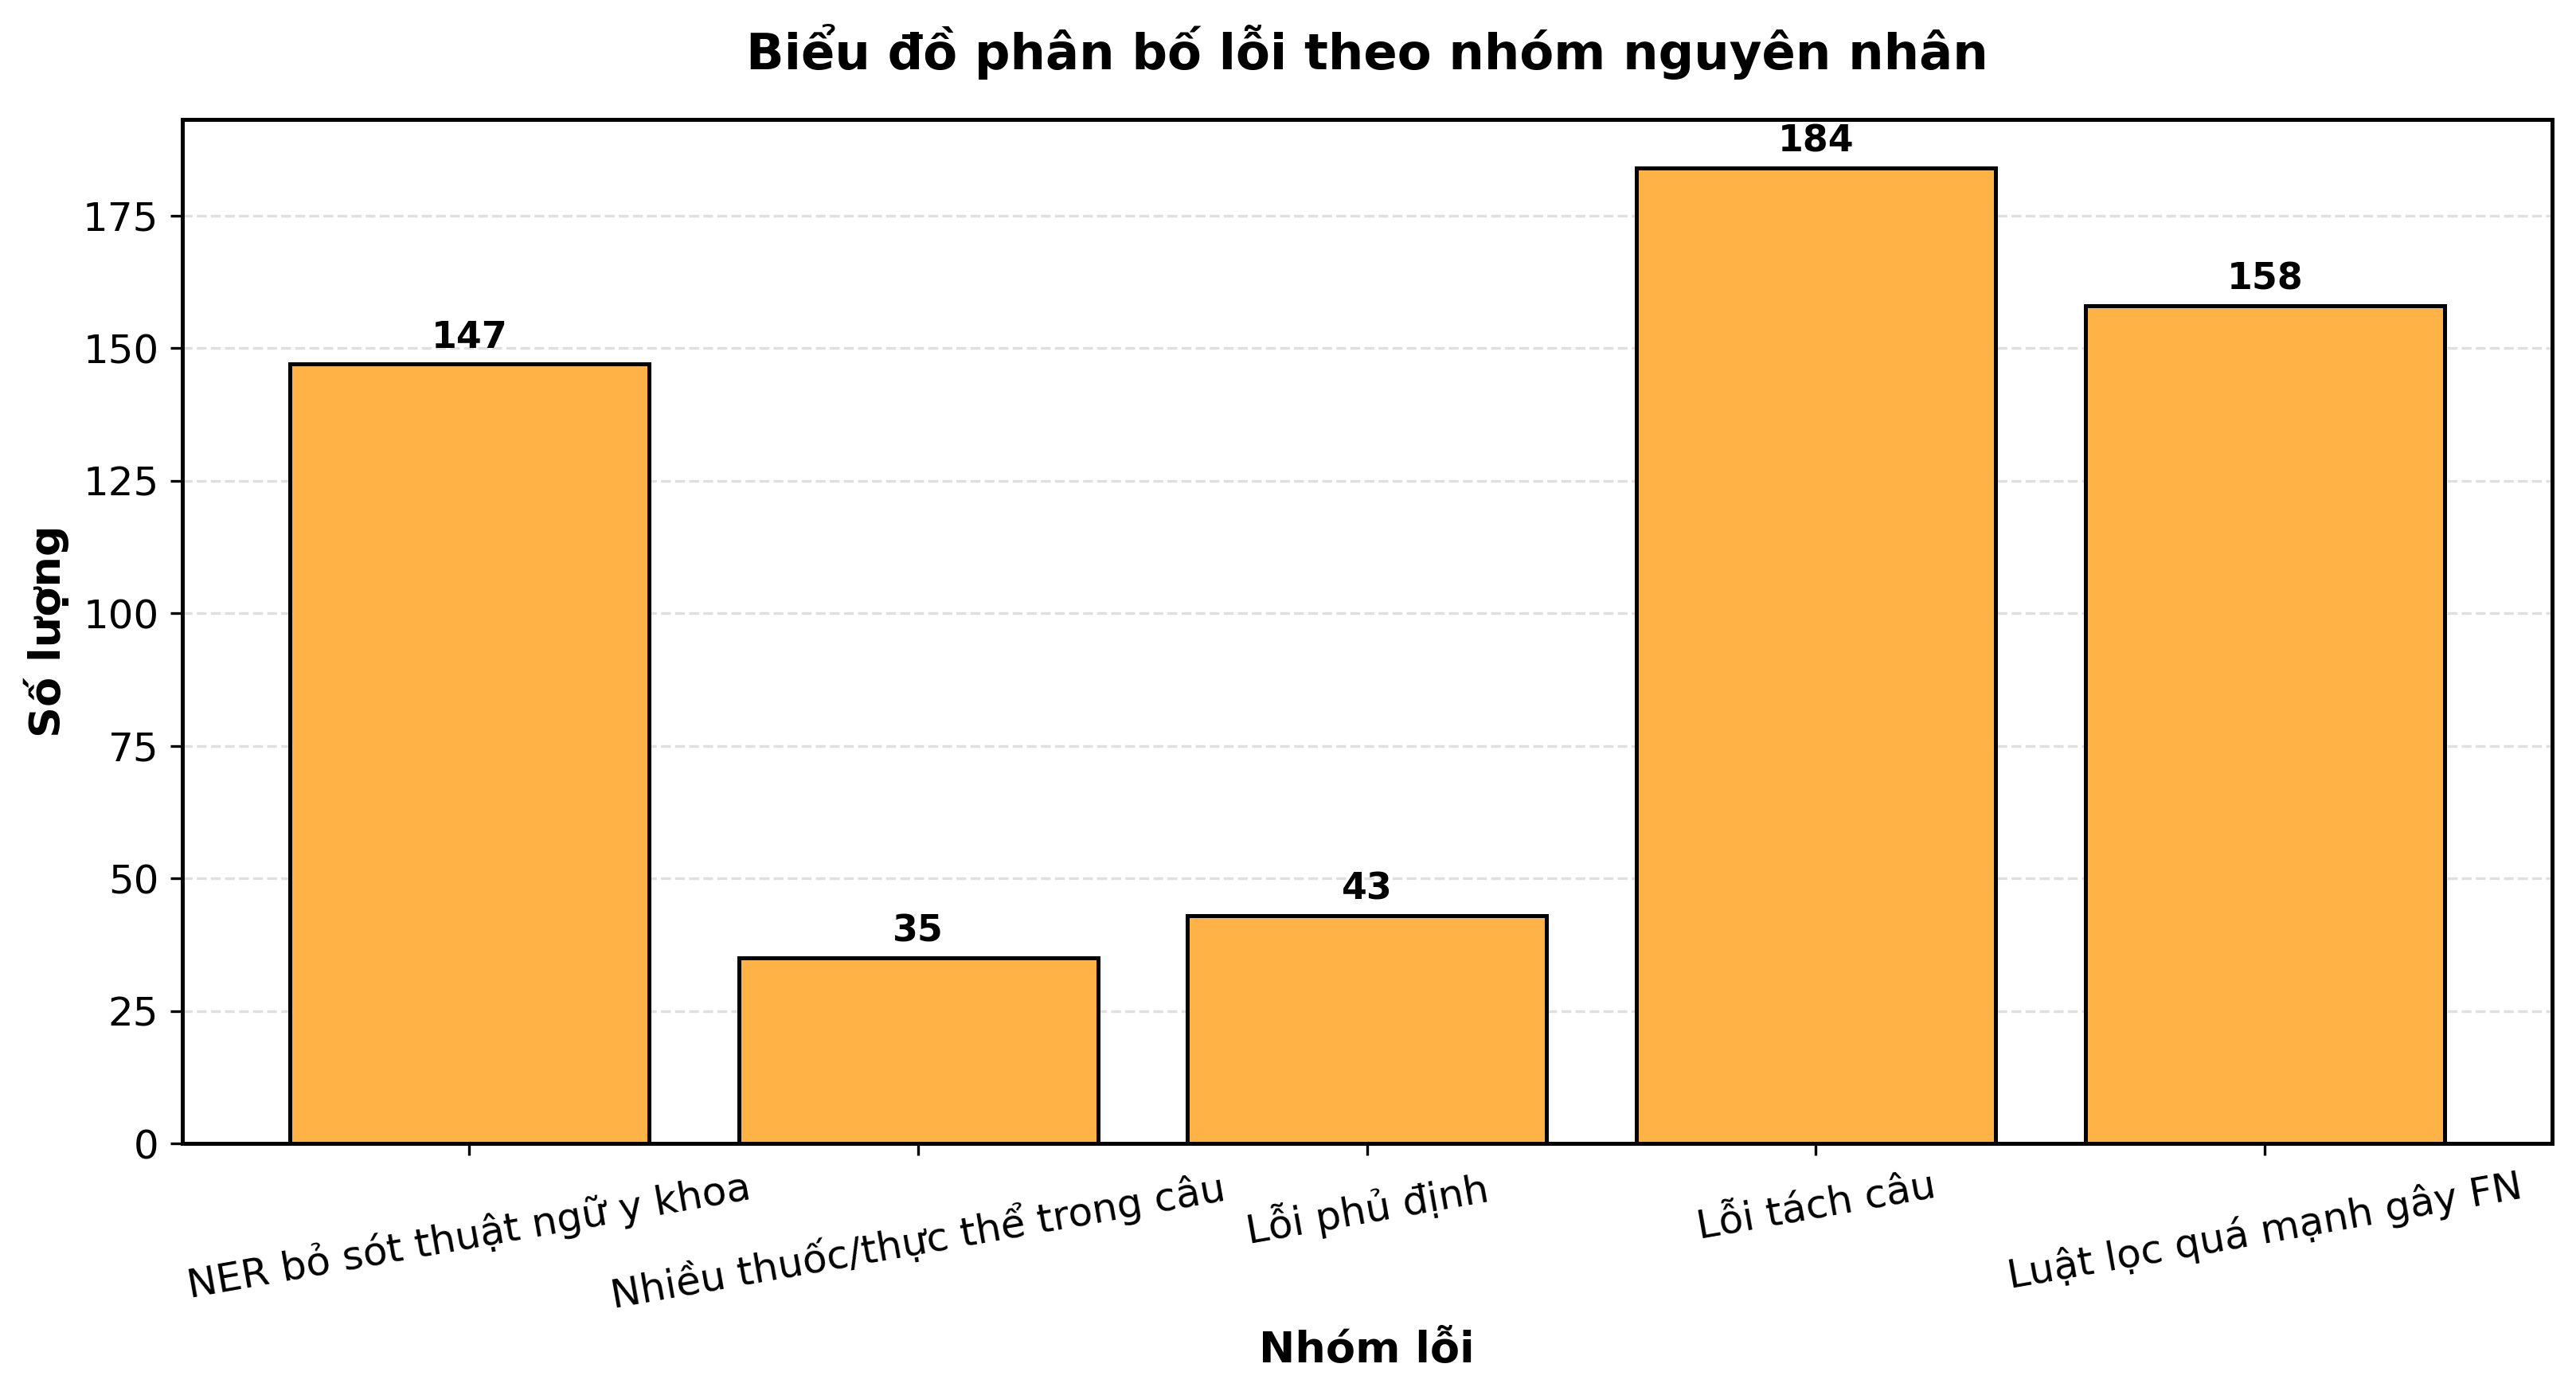


ĐÃ LƯU FILE:
phan_tich_loi\chi_tiet_phan_tich_loi.csv
phan_tich_loi\tong_hop_loi.csv
phan_tich_loi\bieu_do_phan_tich_loi_luan_van.png


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# OUTPUT FOLDER
# =========================
output_folder = "phan_tich_loi"
os.makedirs(output_folder, exist_ok=True)

# =========================
# DATA
# =========================
before = set(all_before)
after = set(all_after)

removed = before - after

# =========================
# STORAGE
# =========================
error_rows = []

summary = {
    "NER bỏ sót thuật ngữ y khoa": 0,
    "Nhiều thuốc/thực thể trong câu": 0,
    "Lỗi phủ định": 0,
    "Lỗi tách câu": 0,
    "Luật lọc quá mạnh gây FN": 0
}

# =========================
# NORMALIZE
# =========================
def norm(x):
    return x.lower().strip()

# =========================
# KNOWLEDGE
# =========================
known_drugs = {
    "lipitor",
    "advil",
    "tylenol",
    "arthrotec",
    "aspirin",
    "ibuprofen"
}

def classify_error(d, a):

    d_n = norm(d)
    a_n = norm(a)

    full_text = d_n + " " + a_n

    # =========================
    # (1) LỖI TÁCH CÂU
    # =========================
    if (
        d_n == "" or
        a_n == "" or
        len(d_n) <= 1 or
        len(a_n) <= 1
    ):
        return "Lỗi tách câu"

    # =========================
    # (2) LỖI PHỦ ĐỊNH
    # =========================
    neg_patterns = ["no", "not", "never", "didn't", "don't", "cannot", "can't", "without"]

    if any(n in full_text for n in neg_patterns):
        return "Lỗi phủ định"

    # =========================
    # (3) NHIỀU THỰC THỂ
    # =========================
    if (
        len(d.split()) > 4 or
        len(a.split()) > 6 or
        "," in a or
        ";" in a
    ):
        return "Nhiều thuốc/thực thể trong câu"

    # =========================
    # (4) NER BỎ SÓT
    # =========================
    bad_entities = {
        "i", "it", "this", "that", "there", "have",
        "and", "of", "for", "when", "will", "with",
        "my", "your"
    }

    # cải tiến: không nằm trong knowledge + không hợp lệ
    if (
        d_n in bad_entities or
        a_n in bad_entities or
        (d_n not in known_drugs and not d_n.isalpha())
    ):
        return "NER bỏ sót thuật ngữ y khoa"

    # =========================
    # (5) LUẬT LỌC QUÁ MẠNH
    # =========================
    return "Luật lọc quá mạnh gây FN"

# =========================
# PHÂN TÍCH LỖI
# =========================
for d, r, a in removed:

    error_type = classify_error(d, a)

    summary[error_type] += 1

    error_rows.append({
        "ThucThe_Thuoc": d,
        "QuanHe": r,
        "ThucThe_TacDungPhu": a,
        "LoaiLoi": error_type
    })

print("Đã phân tích:", len(error_rows), "lỗi")

# =========================
# EXPORT CHI TIẾT LỖI
# =========================
df_detail = pd.DataFrame(error_rows)

detail_path = os.path.join(
    output_folder,
    "chi_tiet_phan_tich_loi.csv"
)

df_detail.to_csv(
    detail_path,
    index=False,
    encoding="utf-8-sig"
)

# =========================
# TẠO DATAFRAME TỔNG HỢP
# =========================
summary_rows = []

for k, v in summary.items():
    summary_rows.append({
        "Nhom_Loi": k,
        "So_Luong": v
    })

df_summary = pd.DataFrame(summary_rows)

# =========================
# EXPORT TỔNG HỢP CSV
# =========================
summary_path = os.path.join(
    output_folder,
    "tong_hop_loi.csv"
)

df_summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)


# =========================
# HIỂN THỊ TỔNG HỢP
# =========================
print("\n=== TỔNG HỢP LỖI ===")
print(df_summary)

# =========================
# STYLE BIỂU ĐỒ
# =========================
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 300

# =========================
# DATA BIỂU ĐỒ
# =========================
labels = df_summary["Nhom_Loi"]
values = df_summary["So_Luong"]

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(11, 6))

# nền trắng
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# =========================
# BAR
# =========================
bars = ax.bar(
    labels,
    values,
    color="#ffb347",
    edgecolor="black",
    linewidth=1.2
)

# =========================
# KHUNG BIỂU ĐỒ
# =========================
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# =========================
# LABELS
# =========================
ax.set_xlabel(
    "Nhóm lỗi",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Số lượng",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "Biểu đồ phân bố lỗi theo nhóm nguyên nhân",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# =========================
# GRID
# =========================
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.4
)

ax.set_axisbelow(True)

# =========================
# HIỂN THỊ GIÁ TRỊ
# =========================
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        str(int(height)),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# =========================
# XOAY NHÃN
# =========================
plt.xticks(rotation=10)

# =========================
# CĂN LỀ
# =========================
plt.tight_layout()

# =========================
# SAVE BIỂU ĐỒ
# =========================
chart_path = os.path.join(
    output_folder,
    "bieu_do_phan_tich_loi_luan_van.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# =========================
# PRINT OUTPUT
# =========================
print("\nĐÃ LƯU FILE:")
print(detail_path)
print(summary_path)

print(chart_path)

In [59]:
# =========================
# LẤY 5 VÍ DỤ MỖI NHÓM LỖI
# =========================
top_examples = []

for error_type in df_detail["LoaiLoi"].unique():

    subset = df_detail[df_detail["LoaiLoi"] == error_type]

    # lấy tối đa 5 ví dụ
    sample = subset.sample(n=min(5, len(subset)), random_state=42)

    top_examples.append(sample)

# gộp lại thành 1 bảng
df_examples = pd.concat(top_examples, ignore_index=True)

# =========================
# EXPORT VÍ DỤ
# =========================
examples_path = os.path.join(
    output_folder,
    "vi_du_5_loi_moi_nhom.csv"
)

df_examples.to_csv(
    examples_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n=== 5 VÍ DỤ MỖI NHÓM LỖI ===")
print(df_examples)

print("\nĐã lưu:", examples_path)


=== 5 VÍ DỤ MỖI NHÓM LỖI ===
   ThucThe_Thuoc  QuanHe                                 ThucThe_TacDungPhu  \
0            EYE  CAUSES                                                      
1        swings,  CAUSES                                                      
2                 CAUSES                                        apple cidar   
3                 CAUSES                                     and confussion   
4                 CAUSES                                          Have felt   
5             in  CAUSES                                                see   
6            did  CAUSES                                         eliminated   
7            all  CAUSES               my diet with any anti-inflammatories   
8          until  CAUSES                                    started to have   
9        surgery  CAUSES                                               drug   
10      breasts,  CAUSES                                              two a   
11            30  CAUS

In [60]:
# =========================
# ĐỌC FILE CHI TIẾT LỖI
# =========================
df_detail = pd.read_csv(
    "phan_tich_loi/chi_tiet_phan_tich_loi.csv"
)

# =========================
# LỌC LỖI TÁCH CÂU
# =========================
df_tach_cau = df_detail[
    df_detail["LoaiLoi"]
    .astype(str)
    .str.strip()
    == "Lỗi tách câu"
]

print("Số lỗi tách câu:", len(df_tach_cau))

# =========================
# LẤY NGẪU NHIÊN 5 VÍ DỤ
# =========================
df_tach_cau_5 = df_tach_cau.sample(
    n=min(5, len(df_tach_cau)),
    random_state=42
).copy()

# reset index
df_tach_cau_5 = df_tach_cau_5.reset_index(drop=True)

# thêm STT
df_tach_cau_5.insert(
    0,
    "STT",
    range(1, len(df_tach_cau_5) + 1)
)

# =========================
# HIỂN THỊ
# =========================
print("\n=== 5 VÍ DỤ LỖI TÁCH CÂU ===")
print(df_tach_cau_5)

# =========================
# EXPORT CSV
# =========================
output_path = "phan_tich_loi/5_vi_du_loi_tach_cau.csv"

df_tach_cau_5.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã lưu:", output_path)

Số lỗi tách câu: 184

=== 5 VÍ DỤ LỖI TÁCH CÂU ===
   STT ThucThe_Thuoc  QuanHe ThucThe_TacDungPhu       LoaiLoi
0    1           EYE  CAUSES                NaN  Lỗi tách câu
1    2       swings,  CAUSES                NaN  Lỗi tách câu
2    3           NaN  CAUSES        apple cidar  Lỗi tách câu
3    4           NaN  CAUSES     and confussion  Lỗi tách câu
4    5           NaN  CAUSES          Have felt  Lỗi tách câu

Đã lưu: phan_tich_loi/5_vi_du_loi_tach_cau.csv
